In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập font và style cho biểu đồ đẹp hơn
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

MASTER_CSV = r'd:/Study/TLCN/data/processed/master_timeseries.csv'
df = pd.read_csv(MASTER_CSV)
df['month_start'] = pd.to_datetime(df['month_start'])
df.head()

,station,month_start,conductivity_mS_per_m,precipitation_sum,temperature_mean,temperature_max,temperature_min,evapotranspiration_sum,windspeed_mean,humidity_mean,shortwave_rad_sum,water_level_m,glofas_discharge_m3s
0,MyTho,1985-01-01,NaN,4.4,25.454839,31.3,20.2,126.87,3.334516,76.161290,580.81,NaN,NaN
1,MyTho,1985-02-01,NaN,39.8,26.757143,32.4,21.6,131.02,3.919286,76.107143,579.33,NaN,NaN
2,MyTho,1985-03-01,NaN,64.1,27.380645,33.7,23.2,158.98,3.845484,74.129032,692.03,NaN,NaN
3,MyTho,1985-04-01,NaN,187.4,27.480000,35.7,23.1,133.72,3.189000,80.900000,607.00,NaN,NaN
4,MyTho,1985-05-01,NaN,279.0,26.664516,32.2,23.3,113.69,2.855484,88.677419,558.97,NaN,NaN


## 1. Data Cleaning
Xử lý các bản ghi bị trùng lặp và các giá trị do quá trình merge Outer Sinh ra.

In [2]:
# 1. Xóa cột bị trùng lặp (Duplicates)
duplicates_count = df.duplicated().sum()
print(f"Số dòng trùng lặp: {duplicates_count}")
df = df.drop_duplicates()

# 2. Xử lý Missing Values (NaN)
print("\nSố lượng Missing Values trên từng cột:")
print(df.isna().sum())

# Chiến lược Fill NaN: Dùng phép nội suy (Interpolation) tuyến tính cho dữ liệu chuỗi thời gian,
# và fillna(method='bfill') / 'ffill' cho những điểm không thể nội suy ở đầu chót ranh giới.
df = df.sort_values(by=['station', 'month_start'])
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df.groupby('station')[col].transform(lambda group: group.interpolate(method='linear', limit_direction='both'))

print("\nSau khi xử lý Missing Values:")
print(df.isna().sum())

Số dòng trùng lặp: 0

Số lượng Missing Values trên từng cột:
station                     0
month_start                 0
conductivity_mS_per_m      73
precipitation_sum           0
temperature_mean            0
temperature_max             0
temperature_min             0
evapotranspiration_sum      0
windspeed_mean              0
humidity_mean               0
shortwave_rad_sum           0
water_level_m             674
glofas_discharge_m3s      531
dtype: int64

Sau khi xử lý Missing Values:
station                     0
month_start                 0
conductivity_mS_per_m       0
precipitation_sum           0
temperature_mean            0
temperature_max             0
temperature_min             0
evapotranspiration_sum      0
windspeed_mean              0
humidity_mean               0
shortwave_rad_sum           0
water_level_m               0
glofas_discharge_m3s      500
dtype: int64


Chuẩn bị DataFrame phân cách riêng cho **Tân Châu** (Lưu lượng) và **Mỹ Tho** (Độ mặn) để dễ Plot.

In [3]:
df_tanchau = df[df['station'] == 'TanChau'].set_index('month_start')
df_mytho = df[df['station'] == 'MyTho'].set_index('month_start')

# Gộp 2 trạm lại cho các phân tích đối chiếu
df_merged = pd.merge(
    df_mytho[['conductivity_mS_per_m', 'temperature_mean', 'evapotranspiration_sum', 'precipitation_sum']],
    df_tanchau[['glofas_discharge_m3s']], 
    left_index=True, 
    right_index=True, 
    how='inner'
)
# Tính toán Độ Mặn (Salinity ppt) từ Khả năng dẫn điện (Conductivity mS/m)
df_merged['salinity_ppt'] = df_merged['conductivity_mS_per_m'] * 0.64


## 2. EDA
### A. Biến động Độ mặn và Lưu lượng nước theo thời gian

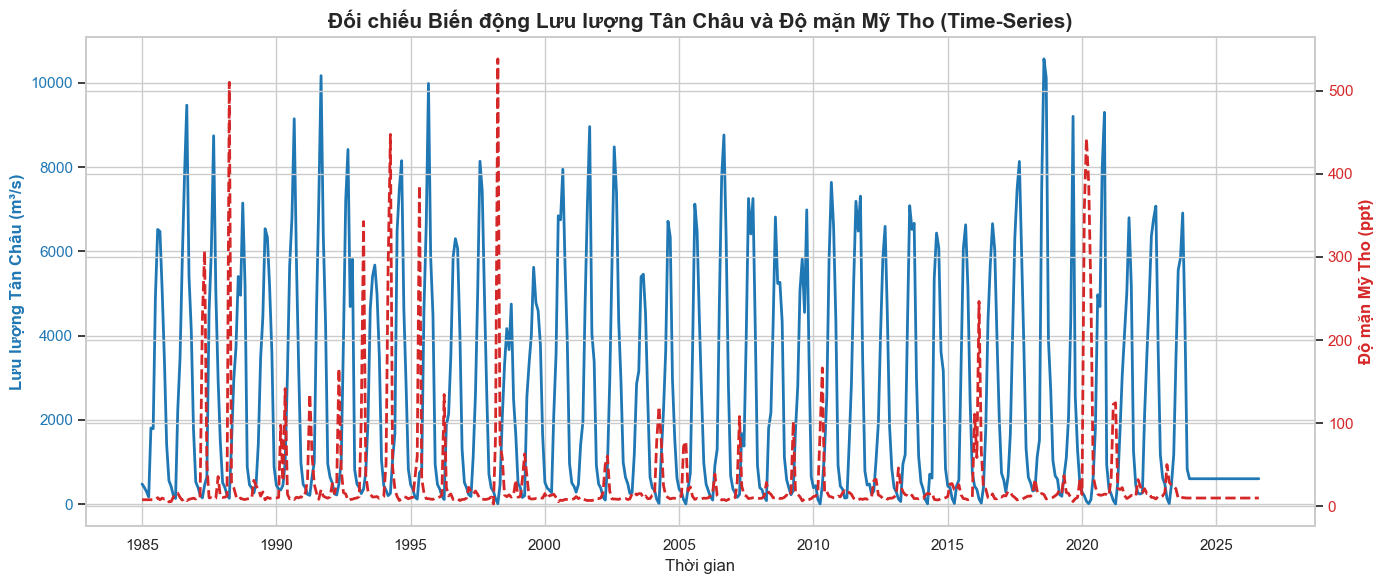

In [4]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Thời gian', fontsize=12)
ax1.set_ylabel('Lưu lượng Tân Châu (m³/s)', color=color, fontsize=12, fontweight='bold')
ax1.plot(df_merged.index, df_merged['glofas_discharge_m3s'], color=color, linewidth=2, label='Lưu lượng (Tân Châu)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Độ mặn Mỹ Tho (ppt)', color=color, fontsize=12, fontweight='bold')  
ax2.plot(df_merged.index, df_merged['salinity_ppt'], color=color, linewidth=2, linestyle='--', label='Độ mặn (Mỹ Tho)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Đối chiếu Biến động Lưu lượng Tân Châu và Độ mặn Mỹ Tho (Time-Series)', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

### B. Phân bố độ mặn theo tháng (Tính Mùa vụ - Seasonality)

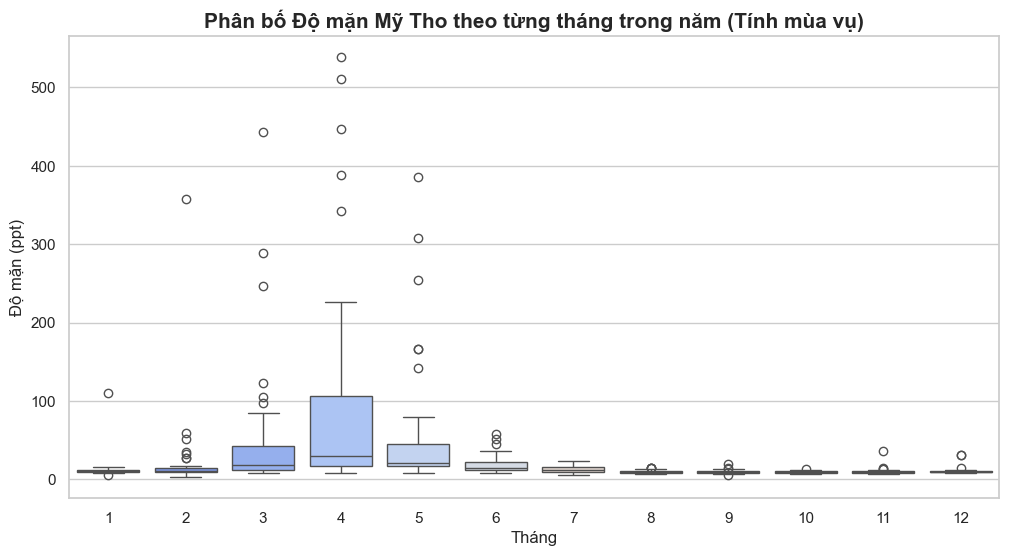

In [5]:
df_merged['month'] = df_merged.index.month

plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='salinity_ppt', data=df_merged, palette='coolwarm')
plt.title('Phân bố Độ mặn Mỹ Tho theo từng tháng trong năm (Tính mùa vụ)', fontsize=15, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Độ mặn (ppt)', fontsize=12)
plt.show()

### C. Ma trận Tương quan (Correlation Heatmap)

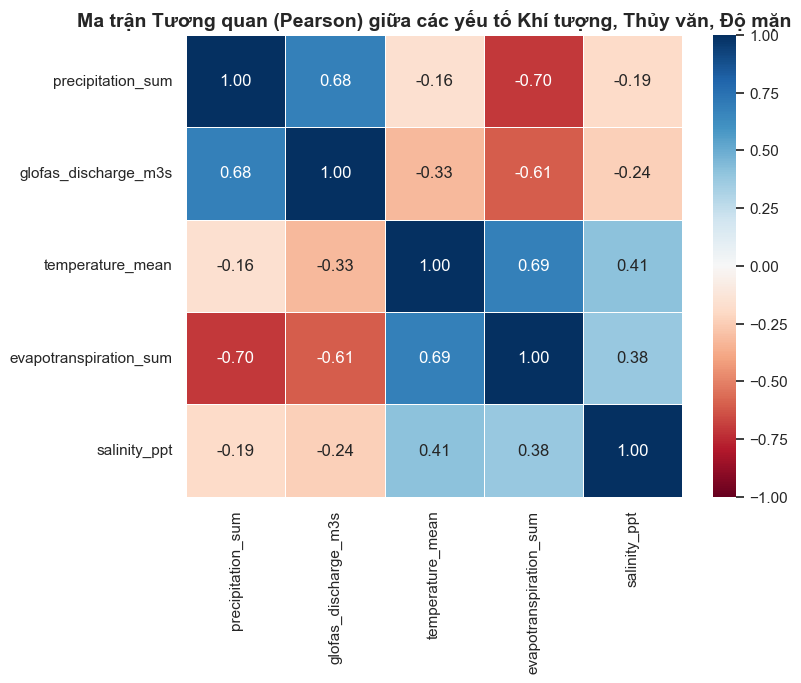

In [6]:
corr_cols = ['precipitation_sum', 'glofas_discharge_m3s', 'temperature_mean', 'evapotranspiration_sum', 'salinity_ppt']
corr_matrix = df_merged[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Ma trận Tương quan (Pearson) giữa các yếu tố Khí tượng, Thủy văn, Độ mặn', fontsize=14, fontweight='bold')
plt.show()

### D. Scatter Plot: Tương quan Lưu lượng - Độ mặn.

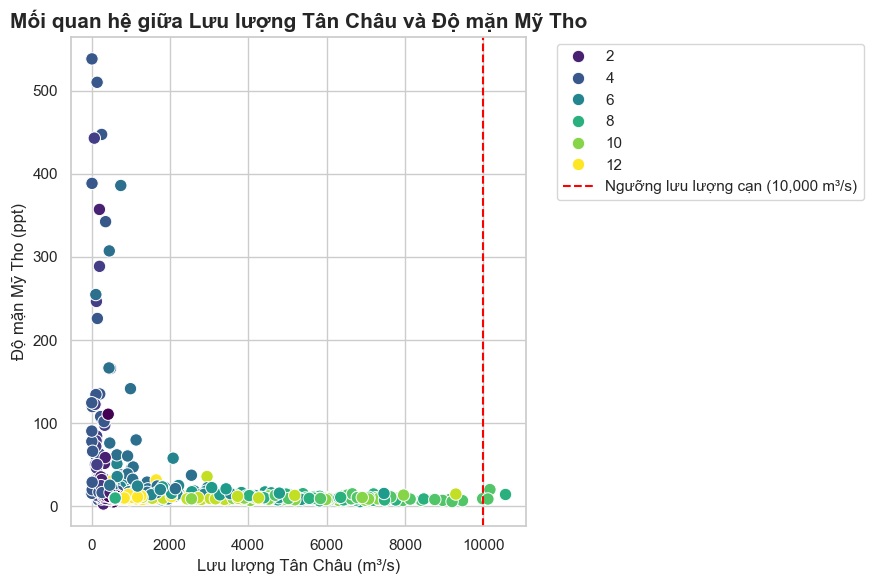

In [7]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x='glofas_discharge_m3s', y='salinity_ppt', hue='month', palette='viridis', data=df_merged, s=80)
plt.title('Mối quan hệ giữa Lưu lượng Tân Châu và Độ mặn Mỹ Tho', fontsize=15, fontweight='bold')
plt.xlabel('Lưu lượng Tân Châu (m³/s)', fontsize=12)
plt.ylabel('Độ mặn Mỹ Tho (ppt)', fontsize=12)
plt.axvline(x=10000, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng lưu lượng cạn (10,000 m³/s)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()